# Creating PySpark Session

Vantage API

In [63]:
import requests
import pandas as pd
from pyspark.sql import SparkSession
import time
from pyspark.sql.functions import lit
from functools import reduce
from pyspark.sql import DataFrame
from io import StringIO

# Initialize PySpark Session
spark = SparkSession.builder.appName("DailyStockMarket").getOrCreate()

# Alpha Vantage API Key (Keep it secure)
API_KEY = "OL3Y0JLVFKSYUGGB"

# List of stock symbols
symbols = ['AAPL', 'GOOG', 'AMZN', 'MSFT', 'TSLA']

output_size = "full"

# Function to fetch daily stock data
def get_daily_stock_data(symbol):
    url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={symbol}&outputsize={output_size}&apikey={API_KEY}&datatype=csv"
    
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()  # Raise an error for bad responses (4xx, 5xx)

        # Read CSV response into Pandas DataFrame
        df = pd.read_csv(StringIO(response.text))
        
        # Convert to PySpark DataFrame
        spark_df = spark.createDataFrame(df)

        # Add symbol column
        spark_df = spark_df.withColumn("symbol", lit(symbol))

        return spark_df
    
    except requests.exceptions.RequestException as e:
        print(f"Error fetching data for {symbol}: {e}")
        return None

# List to store DataFrames
stock_dfs = []

# Fetch data for all symbols
for symbol in symbols:
    print(f"Fetching daily data for {symbol}...")
    df = get_daily_stock_data(symbol)

    if df:
        stock_dfs.append(df)
        print(f"Successfully loaded daily data for {symbol}")

    time.sleep(15)  # Avoid hitting API rate limits

# Merge all DataFrames efficiently
if stock_dfs:
    spark_df = reduce(DataFrame.unionAll, stock_dfs)
    print("Combined daily stock data sample:")
    spark_df.show(5)
else:
    print("No data fetched.")


Fetching daily data for AAPL...
Successfully loaded daily data for AAPL
Fetching daily data for GOOG...
Successfully loaded daily data for GOOG
Fetching daily data for AMZN...
Successfully loaded daily data for AMZN
Fetching daily data for MSFT...
Successfully loaded daily data for MSFT
Fetching daily data for TSLA...
Successfully loaded daily data for TSLA
Combined daily stock data sample:
+----------+------+--------+------+------+--------+------+
| timestamp|  open|    high|   low| close|  volume|symbol|
+----------+------+--------+------+------+--------+------+
|2025-03-21|211.56|  218.84|211.28|218.27|94127768|  AAPL|
|2025-03-20|213.99|217.4899|212.22| 214.1|48862947|  AAPL|
|2025-03-19|214.22|  218.76|213.75|215.24|54385391|  AAPL|
|2025-03-18|214.16|  215.15|211.49|212.69|42432426|  AAPL|
|2025-03-17|213.31|  215.22|209.97| 214.0|48073426|  AAPL|
+----------+------+--------+------+------+--------+------+
only showing top 5 rows



# Data Characteristics

In [64]:
#Number of rows
num_rows = spark_df.count()
num_rows

25628

In [60]:
#Number of columns
num_columns = len(spark_df.columns)
num_columns

7

In [61]:
# Print the shape
print("Shape of the PySpark DataFrame: ({}, {})".format(num_rows, num_columns))

Shape of the PySpark DataFrame: (500, 7)


In [65]:
from pyspark.sql import functions as F

# Range of timestamps
date_range = spark_df.agg(F.min("timestamp").alias("min_timestamp"), F.max("timestamp").alias("max_timestamp")).collect()[0]

# Display date range
print(f"Data ranges from {date_range['min_timestamp']} to {date_range['max_timestamp']}")


Data ranges from 1999-11-01 to 2025-03-21


In [66]:
# Count distinct companies based on the "symbol" column
total_companies_count = spark_df.agg(F.countDistinct("symbol")).collect()[0][0]

# Display the count
print(f"Total number of unique companies: {total_companies_count}")


Total number of unique companies: 5


In [67]:
# Datatype
spark_df.printSchema()

root
 |-- timestamp: string (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: long (nullable = true)
 |-- symbol: string (nullable = false)



date -> date format and is used for storing date-related information

symbol -> string

volume -> long (i.e., integer)

open, high, low, close, and adjclose -> double (i.e., floating point)

In [4]:
!pip install findspark

In [68]:
# Importing necessary libraries
import findspark
import pyspark
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, sum
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql import SparkSession

# Creating a PySpark session
spark = SparkSession.builder.appName("StockMarketAnalysis").getOrCreate()


# Data Preprocessing

In [69]:
from pyspark.sql.functions import col, sum

# Check for null values in each column
missing_values = df.select([sum(col(column).isNull().cast("int")).alias(column) for column in df.columns])

# Show missing values count for each column
missing_values.show()


+---------+----+----+---+-----+------+------+
|timestamp|open|high|low|close|volume|symbol|
+---------+----+----+---+-----+------+------+
|        0|   0|   0|  0|    0|     0|     0|
+---------+----+----+---+-----+------+------+



As there are no missing values, no handling of null operation is performed.

# Select 3 stocks

In [70]:
# List of company symbols

company_symbols = ['AAPL', 'GOOG', 'AMZN']


# Filter stocks

In [71]:
# List of 3 company symbols
company_symbols = ['AAPL', 'GOOG', 'AMZN']

from pyspark.sql.functions import col, count

# Filter DataFrame for 5 company symbols
company_df = spark_df.filter(col('symbol').isin(company_symbols))

# Check entry counts for each car company symbol
company_counts = company_df.groupBy('symbol').agg(count('*').alias('entry_count')).orderBy('entry_count', ascending=False)

# Display the result
company_counts.show(truncate=False)


+------+-----------+
|symbol|entry_count|
+------+-----------+
|AAPL  |6386       |
|AMZN  |6386       |
|GOOG  |2764       |
+------+-----------+



In [72]:
# List of symbols for 3 companies
companies = ['AAPL', 'GOOG', 'AMZN']

# Combine all 5 company symbols
all_symbols = companies

# Filter data for each industry
filtered_df = spark_df.filter(col('symbol').isin(all_symbols))

# Show the filtered data
filtered_df.show()

+----------+-------+--------+--------+------+--------+------+
| timestamp|   open|    high|     low| close|  volume|symbol|
+----------+-------+--------+--------+------+--------+------+
|2025-03-21| 211.56|  218.84|  211.28|218.27|94127768|  AAPL|
|2025-03-20| 213.99|217.4899|  212.22| 214.1|48862947|  AAPL|
|2025-03-19| 214.22|  218.76|  213.75|215.24|54385391|  AAPL|
|2025-03-18| 214.16|  215.15|  211.49|212.69|42432426|  AAPL|
|2025-03-17| 213.31|  215.22|  209.97| 214.0|48073426|  AAPL|
|2025-03-14| 211.25|  213.95|  209.58|213.49|60107582|  AAPL|
|2025-03-13| 215.95|216.8394|  208.42|209.68|61368330|  AAPL|
|2025-03-12| 220.14|  221.75|  214.91|216.98|62547467|  AAPL|
|2025-03-11|223.805|225.8399|  217.45|220.84|76137410|  AAPL|
|2025-03-10| 235.54|  236.16|  224.22|227.48|71451281|  AAPL|
|2025-03-07|235.105|  241.37|  234.76|239.07|46273565|  AAPL|
|2025-03-06|234.435|  237.86|233.1581|235.33|45170419|  AAPL|
|2025-03-05| 235.42|  236.55|  229.23|235.74|47227643|  AAPL|
|2025-03

# Check Outliers

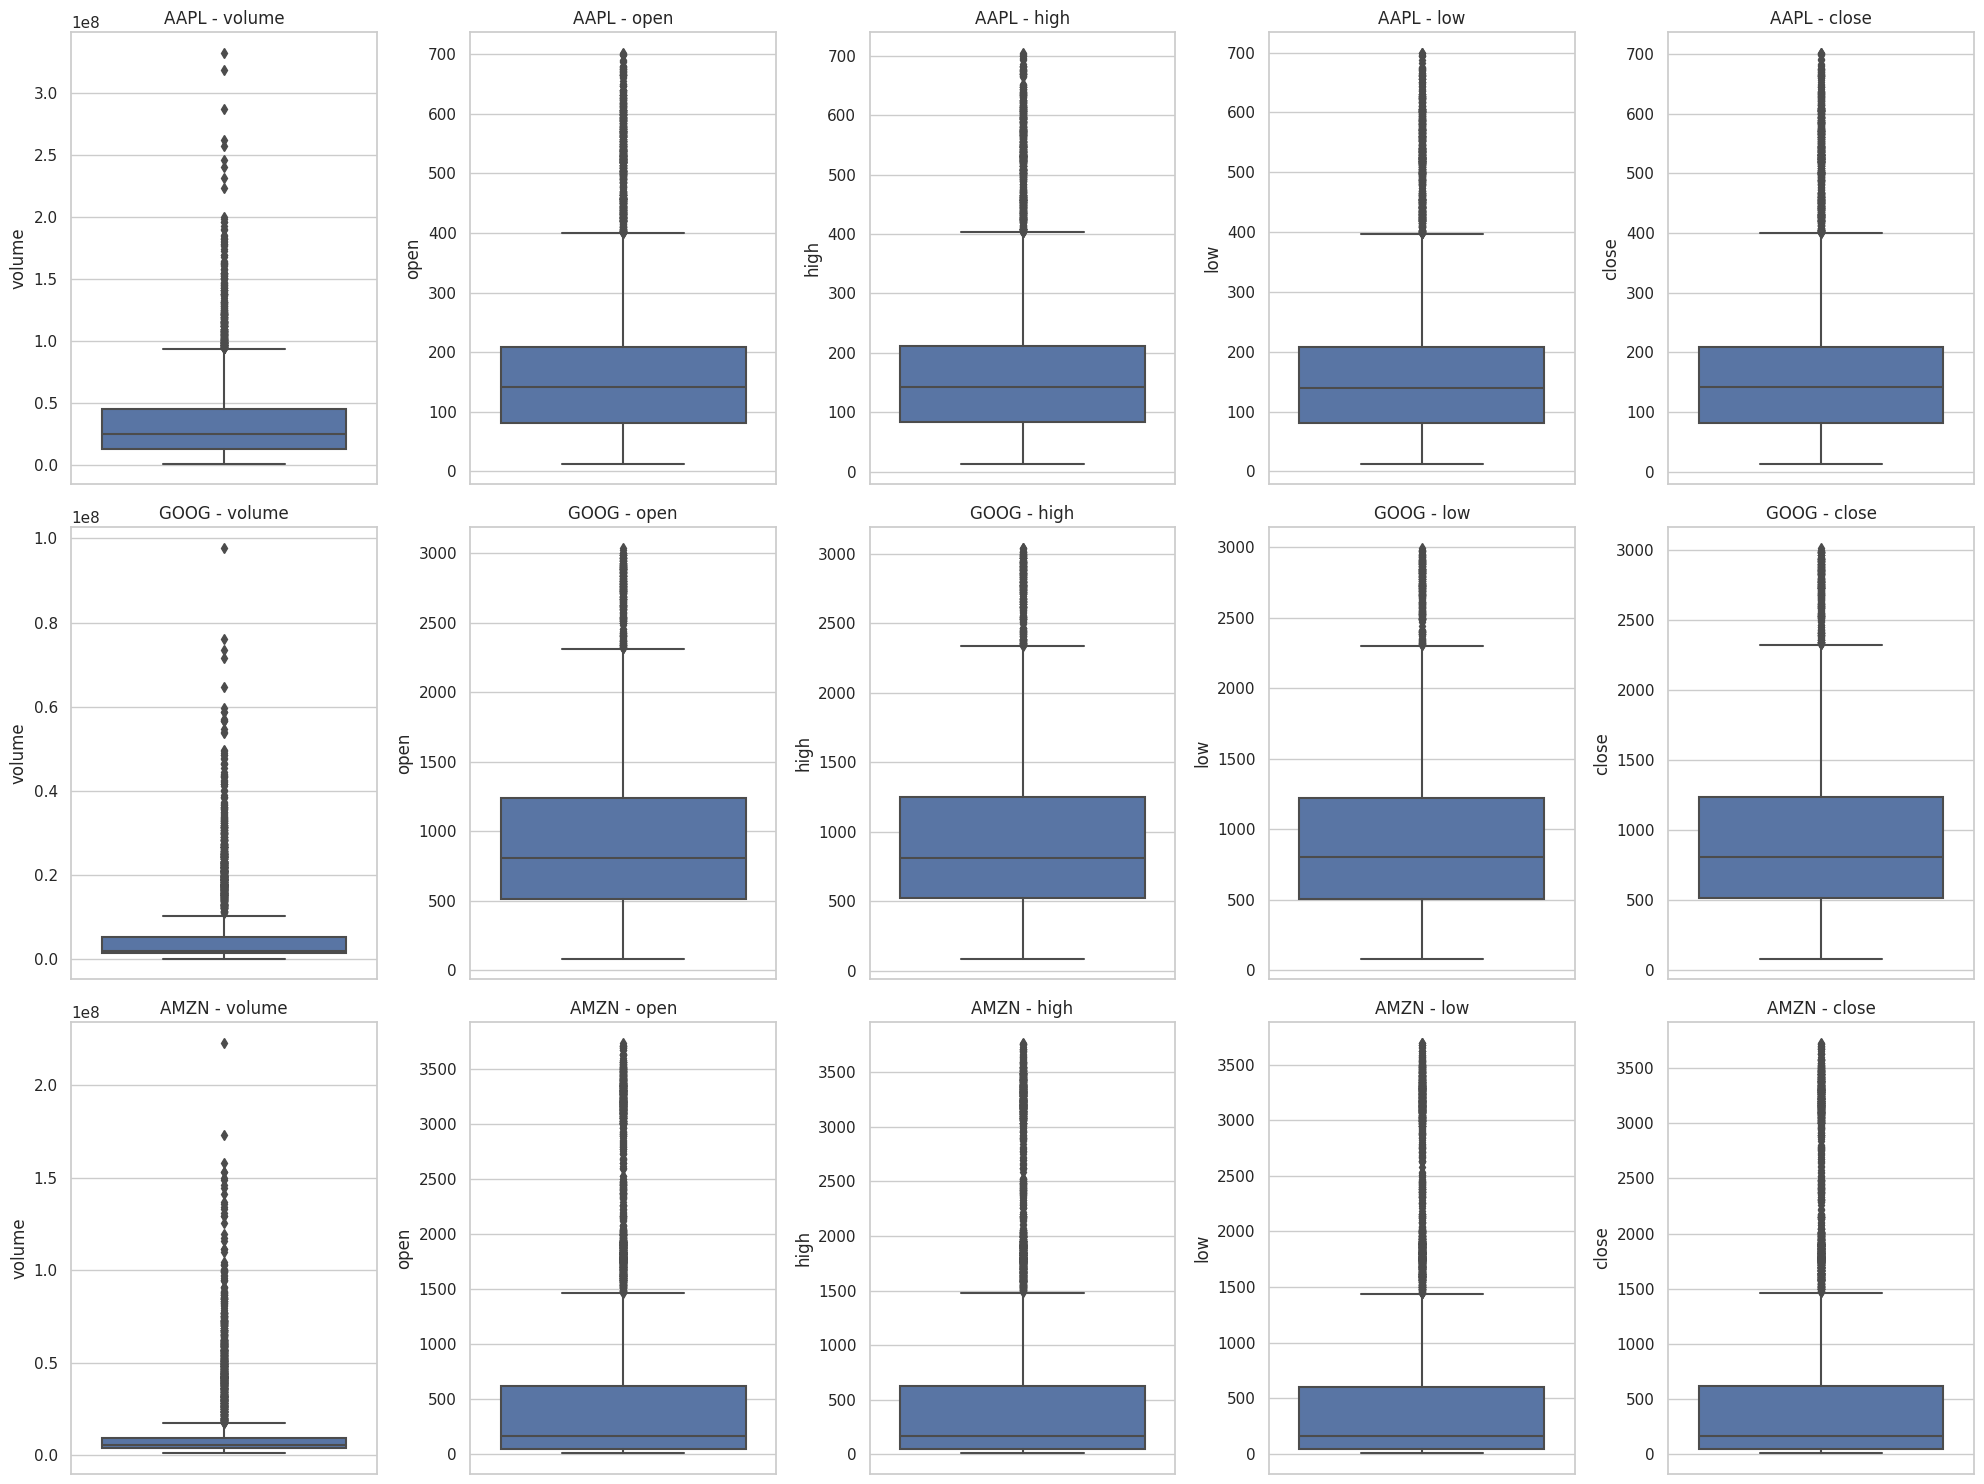

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F

# List of selected companies
companies = ['AAPL', 'GOOG', 'AMZN']

# Filter DataFrame for selected companies
filtered_df = spark_df.filter(F.col('symbol').isin(companies))

# Convert 'timestamp' to proper datetime format
filtered_df = filtered_df.withColumn('timestamp', F.to_timestamp(F.col('timestamp')))

# Get unique stock symbols
unique_symbols = [row['symbol'] for row in filtered_df.select('symbol').distinct().collect()]

# Columns for box plots
selected_columns = ['volume', 'open', 'high', 'low', 'close']

plt.figure(figsize=(20, 15))

for i, symbol in enumerate(unique_symbols):
    # Convert to Pandas DataFrame
    symbol_df = filtered_df.filter(F.col('symbol') == symbol).select(selected_columns).toPandas()

    for j, column in enumerate(selected_columns):
        plt.subplot(len(unique_symbols), len(selected_columns), i * len(selected_columns) + j + 1)
        sns.boxplot(y=symbol_df[column])
        plt.title(f"{symbol} - {column}")

plt.tight_layout()
plt.show()


Although there are outliers, it is not advisable to remove or modify them, which may provide significant market events.

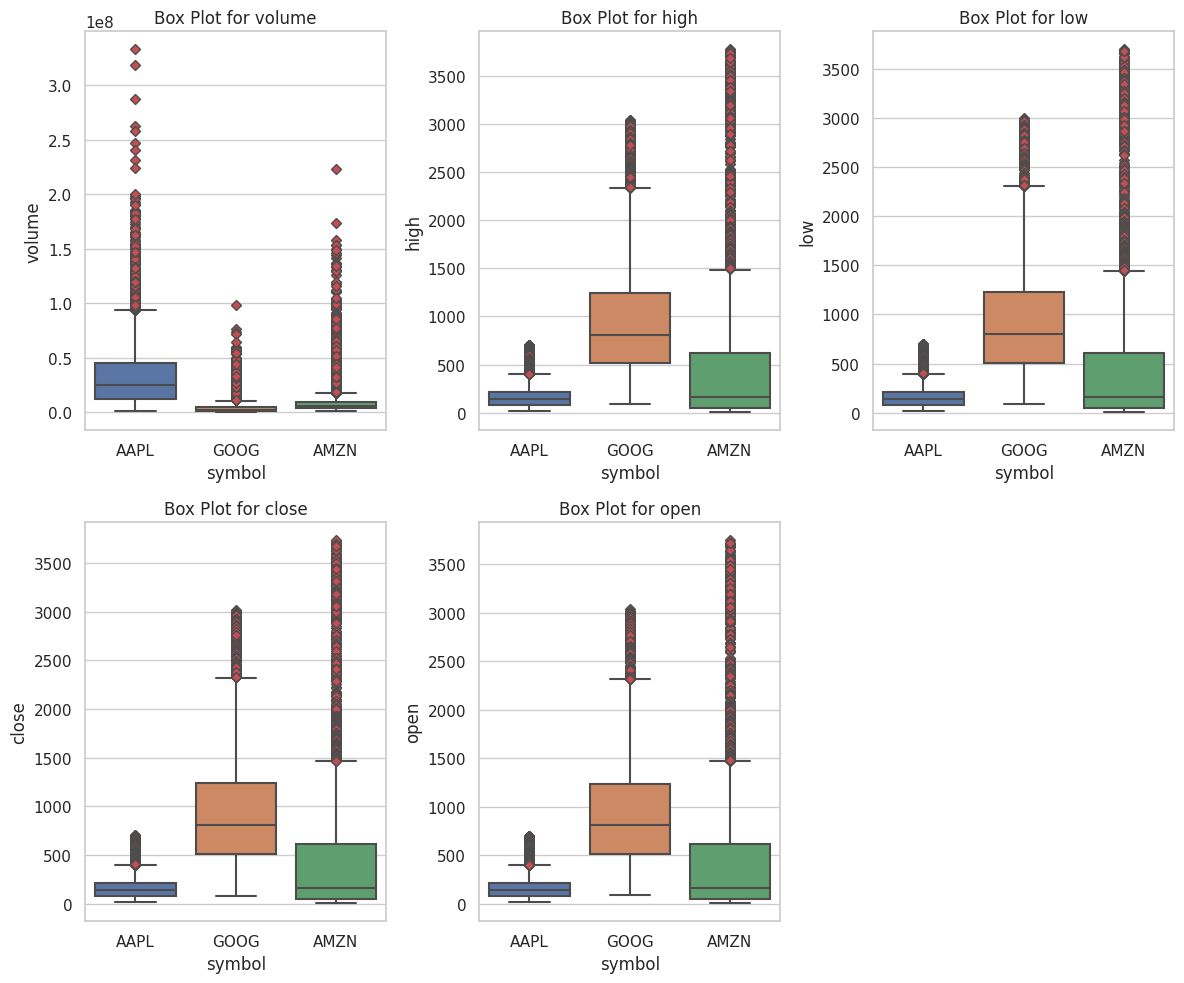

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert PySpark DataFrame to Pandas DataFrame
pandas_df = filtered_df.toPandas()

# Select numerical columns (removed 'adjclose')
numerical_columns = ['volume', 'high', 'low', 'close', 'open']

# Set up the plot
plt.figure(figsize=(12, 10))
sns.set(style="whitegrid")

# Loop through numerical columns and plot
for i, column in enumerate(numerical_columns):
    plt.subplot(2, 3, i + 1)  # Adjusted subplot positioning
    sns.boxplot(data=pandas_df, x='symbol', y=column, showfliers=True,
                flierprops=dict(markerfacecolor='r', marker='D'))
    plt.title(f'Box Plot for {column}')

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


# Exploratory Data Analysis

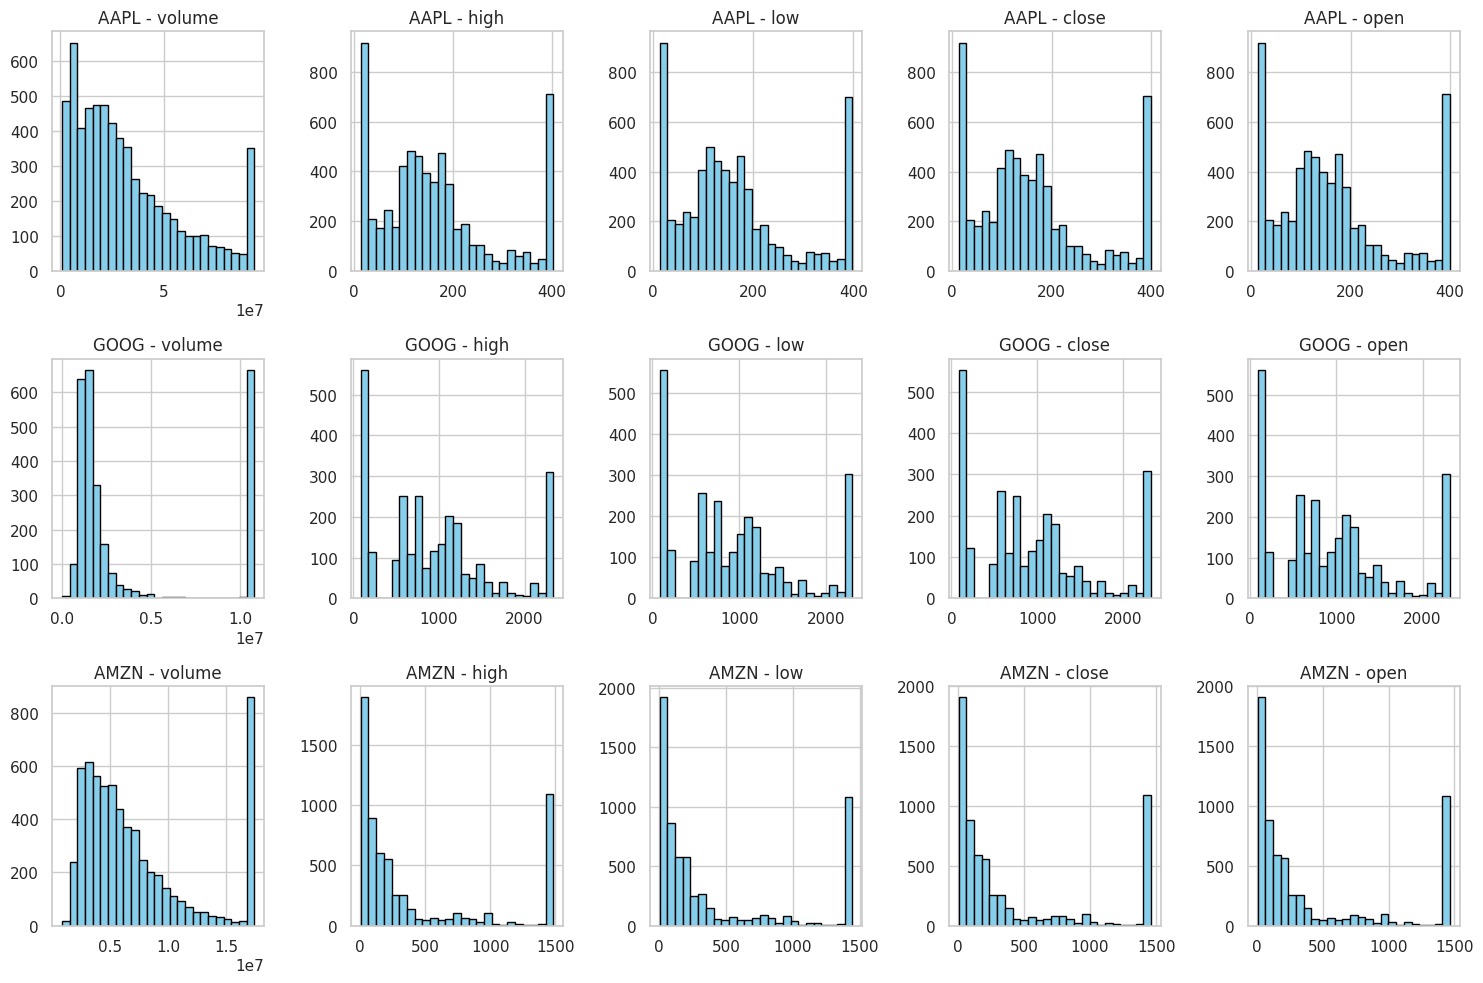

In [75]:
import matplotlib.pyplot as plt
import pyspark.sql.functions as F

# List of companies to analyze
companies = ['AAPL', 'GOOG', 'AMZN']

# Filter data for selected companies
filtered_df = spark_df.filter(F.col('symbol').isin(companies))

# Convert 'timestamp' to proper datetime format
filtered_df = filtered_df.withColumn('timestamp', F.to_timestamp(F.col('timestamp')))

# Define IQR factor for outlier capping
iqr_factor = 1.5

# Select relevant numerical columns (removed 'adjclose')
selected_columns = ['volume', 'high', 'low', 'close', 'open']

# Create Histograms
plt.figure(figsize=(15, 10))

# Loop through each symbol for histograms
for i, symbol in enumerate(companies):
    # Convert PySpark DataFrame to Pandas DataFrame
    symbol_df = filtered_df.filter(F.col('symbol') == symbol).select(selected_columns).toPandas()

    # Apply IQR-based outlier capping
    for column in selected_columns:
        Q1 = symbol_df[column].quantile(0.25)
        Q3 = symbol_df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - iqr_factor * IQR
        upper_limit = Q3 + iqr_factor * IQR
        symbol_df[column] = symbol_df[column].clip(lower=lower_limit, upper=upper_limit)

    # Plot histograms for each numerical column
    for j, column in enumerate(selected_columns):
        plt.subplot(len(companies), len(selected_columns), i * len(selected_columns) + j + 1)
        plt.hist(symbol_df[column], bins=25, color='skyblue', edgecolor='black')  # Adjust bins for better distribution
        plt.title(f"{symbol} - {column}")

# Adjust layout
plt.tight_layout()
plt.show()


Histograms are used for continuous variables.

APPL and AMZN have the highest volume

The highest price rate (high, low, close, and adjclose) is for AMZN; and lowest for MSFT


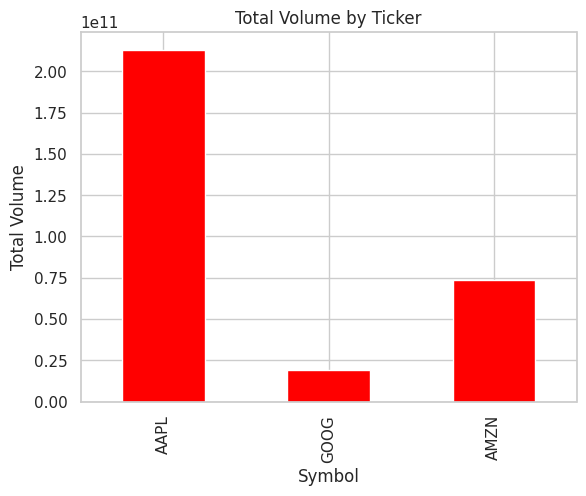

In [76]:
# List of symbols for 3 companies
companies = ['AAPL', 'GOOG', 'AMZN']

# Combine all 5 company symbols
all_symbols = companies

# Filter data for each industry
filtered_df = spark_df.filter(F.col('symbol').isin(all_symbols))

# Calculate total volume for each symbol
total_volume_df = filtered_df.groupBy('symbol').agg(F.sum('volume').alias('total_volume'))

# Convert PySpark DataFrame to Pandas for plotting
total_volume_pd = total_volume_df.toPandas()

# Plot total volume for each symbol using bar plot
total_volume_pd.plot(kind='bar', x='symbol', y='total_volume', color='red', legend=False)

plt.xlabel('Symbol')
plt.ylabel('Total Volume')
plt.title('Total Volume by Ticker')
plt.show()

The number of stocks for each company is represented by bar graph, where APPL has the highest followed by MSFT.

Available Symbols in Data: ['AAPL', 'GOOG', 'AMZN', 'MSFT', 'TSLA']


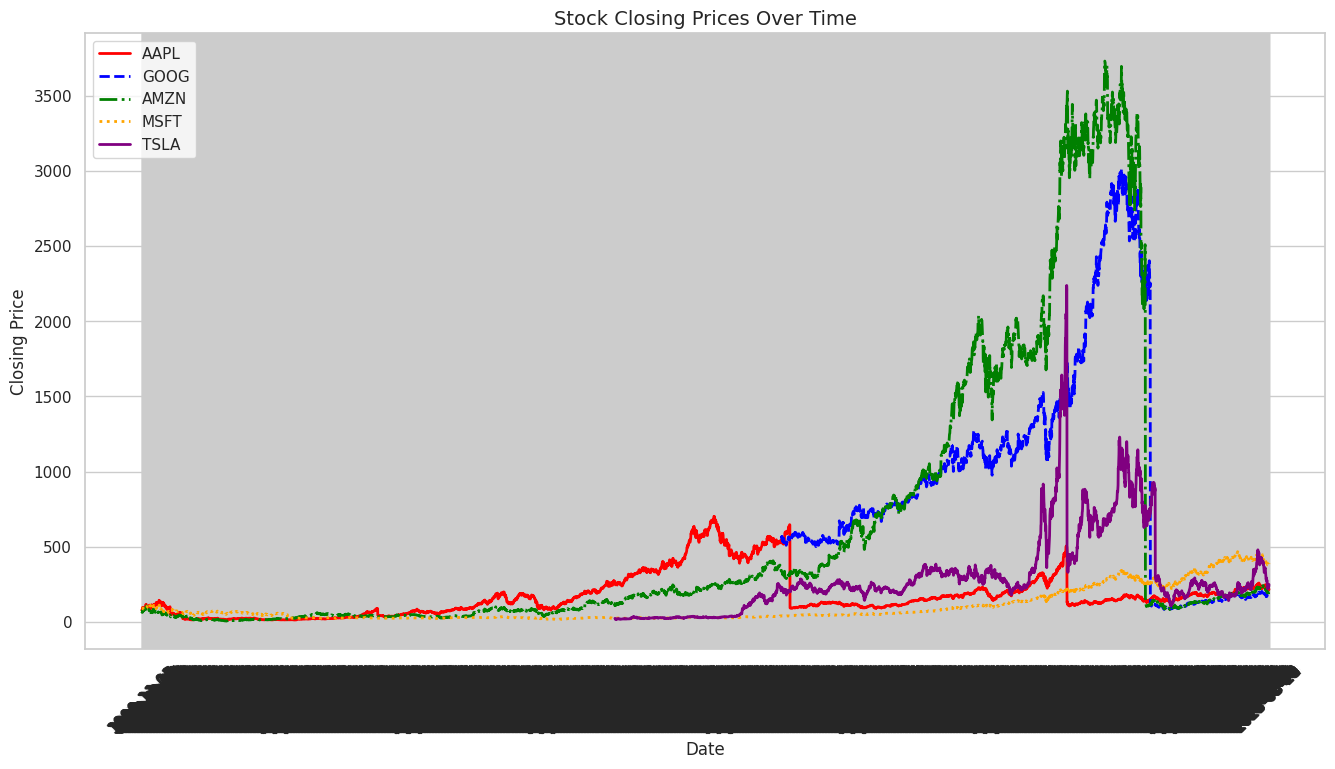

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql.functions import col

# List of stock symbols
companies = ['AAPL', 'GOOG', 'AMZN', 'MSFT', 'TSLA']

# Filter data for selected companies
filtered_df = spark_df.filter(col('symbol').isin(companies))

# Check if all companies have data
available_symbols = [row['symbol'] for row in filtered_df.select('symbol').distinct().collect()]
print("Available Symbols in Data:", available_symbols)

# Dictionary to store company data
company_data = {}

# Extract and convert data for each company
for company in companies:
    company_df = (
        filtered_df.filter(col('symbol') == company)
        .select('timestamp', 'close')
        .orderBy('timestamp')
    ).toPandas()

    if not company_df.empty:
        company_data[company] = company_df  # Store in dictionary

# Plot setup
plt.figure(figsize=(16, 8))
colors = ['red', 'blue', 'green', 'orange', 'purple']
linestyles = ['solid', 'dashed', 'dashdot', 'dotted', 'solid']

# Plot data for each company
for idx, company in enumerate(companies):
    if company in company_data:
        plt.plot(company_data[company]['timestamp'], company_data[company]['close'],
                 color=colors[idx], label=company, linestyle=linestyles[idx], linewidth=2)

# Formatting
plt.title('Stock Closing Prices Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price', fontsize=12)
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.grid(True)

# Show plot
plt.show()


A line graph between 2015-2020 years and closing price is plotted. A clear upward trend is visible in the stock prices of Amazon (AMZN) from 2015 to 2020, where the exponential growth is seen after 2018. In the beginning of 2015, Google (GOOG) exhibited the highest stock price but later surpassed by AMZN, especially in mid-2016. Although there were variations for Tesla (TSLA), it seems to be more steady till 2020. In 2019 and mid-2019, AMZN and GOOG have a major dip, and in post-2020, except Microsoft (MSFT), all other stocks are increased and decreased and then finally increased again. There were no major changes in Apple (APPL) and MSFT. In conclusion, there were a lot of transactions happen in AMZN when compared to other 4 stocks.

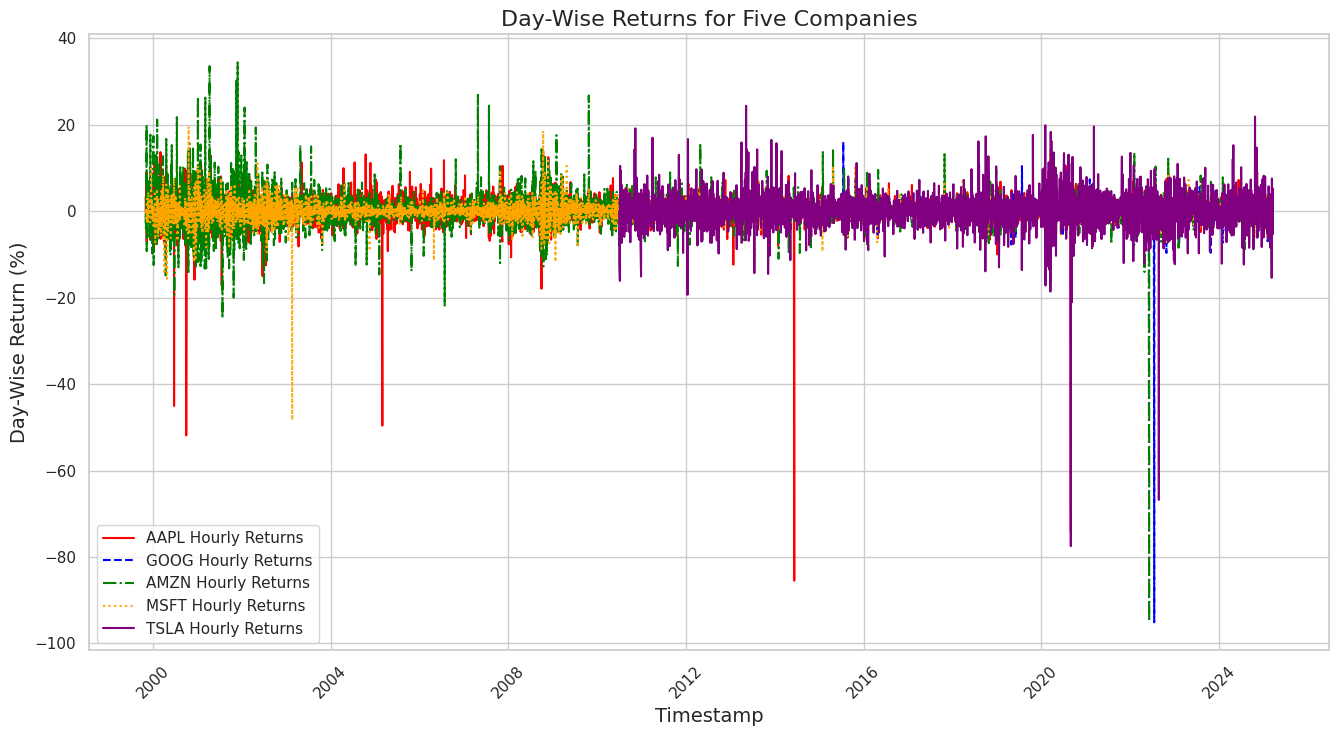

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import col

# List of 5 company symbols
company_symbols = ['AAPL', 'GOOG', 'AMZN', 'MSFT', 'TSLA']

# Filter data for selected companies & order by timestamp (instead of 'date')
data = filtered_df.filter(col('symbol').isin(company_symbols)).orderBy(['symbol', 'timestamp'])

# Define a Window partitioned by symbol (to compute per-company hourly returns)
windowSpec = Window.partitionBy('symbol').orderBy('timestamp')

# Calculate hourly returns using lag function within the Window
data = data.withColumn('lag_close', F.lag('close').over(windowSpec))
data = data.withColumn('hourly_return', ((F.col('close') / F.col('lag_close')) - 1) * 100)

# Fill missing values (first row per stock will have NULL hourly return)
data = data.fillna({'hourly_return': 0.0})

# Convert to Pandas for plotting
comp_pd = data.toPandas()
comp_pd['timestamp'] = pd.to_datetime(comp_pd['timestamp'])  # Ensure correct date format

# Set up the plot
plt.figure(figsize=(16, 8))
colors = ['red', 'blue', 'green', 'orange', 'purple']
linestyles = ['solid', 'dashed', 'dashdot', 'dotted', 'solid']

# Plot hourly returns for each company
for idx, symbol in enumerate(company_symbols):
    symbol_data = comp_pd[comp_pd['symbol'] == symbol]
    plt.plot(symbol_data['timestamp'], symbol_data['hourly_return'],
             label=f'{symbol} Hourly Returns', color=colors[idx], linestyle=linestyles[idx], linewidth=1.5)

# Formatting
plt.xlabel('Timestamp', fontsize=14)
plt.ylabel('Day-Wise Return (%)', fontsize=14)
plt.title('Day-Wise Returns for Five Companies', fontsize=16)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Show plot
plt.show()


Daily returns are calculated to check the day-to-day fluctuations in prcining of each stocks. AMZN displayed a remarkable daily return percentage, touching 1000 in 2019. In the beginning, TSLA was leading when all 5 stocks first taken into consideration then it started to have lot of fluctautions with a drop of nearly 100 in the mid-2019. GOOG and APPL has less volatility with some overlaps inbetween both. There is no change in MSFT daily returns. Overall, AMZN has the best daily returns, whereas MSFT is the wordt.

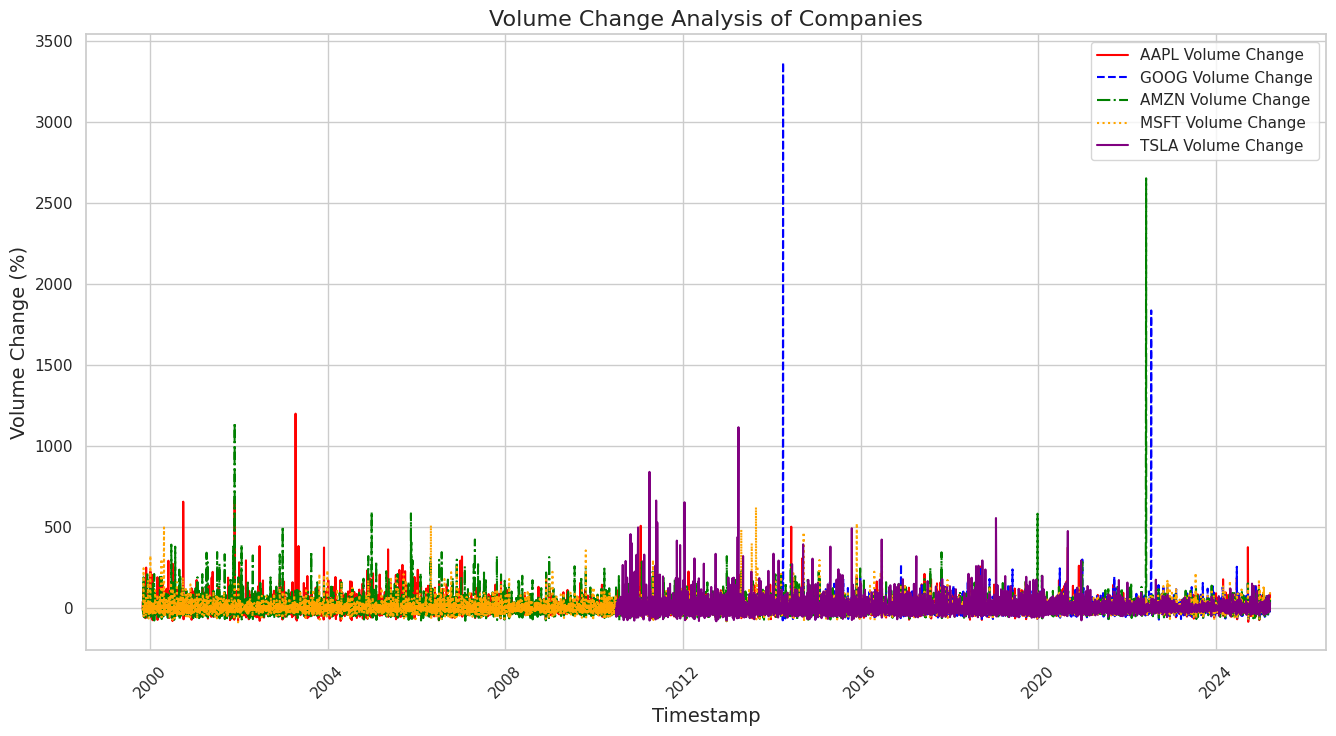

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import col

# List of company symbols
company_symbols = ['AAPL', 'GOOG', 'AMZN', 'MSFT', 'TSLA']

# Filter data for selected companies & order by timestamp (instead of 'date')
data = filtered_df.filter(col('symbol').isin(company_symbols)).orderBy(['symbol', 'timestamp'])

# Define a Window partitioned by symbol (to compute per-company volume change)
windowSpec = Window.partitionBy('symbol').orderBy('timestamp')

# Calculate volume change using lag function within the Window
data = data.withColumn('lag_volume', F.lag('volume').over(windowSpec))
data = data.withColumn('volume_change', ((F.col('volume') / F.col('lag_volume')) - 1) * 100)

# Fill missing values (first row per stock will have NULL volume change)
data = data.fillna({'volume_change': 0.0})

# Convert PySpark DataFrame to Pandas for plotting
comp_pd = data.toPandas()
comp_pd['timestamp'] = pd.to_datetime(comp_pd['timestamp'])  # Ensure correct date format

# Set up the plot
plt.figure(figsize=(16, 8))
colors = ['red', 'blue', 'green', 'orange', 'purple']
linestyles = ['solid', 'dashed', 'dashdot', 'dotted', 'solid']

# Plot volume change for each company
for idx, symbol in enumerate(company_symbols):
    symbol_data = comp_pd[comp_pd['symbol'] == symbol]
    plt.plot(symbol_data['timestamp'], symbol_data['volume_change'],
             label=f'{symbol} Volume Change', color=colors[idx], linestyle=linestyles[idx], linewidth=1.5)

# Formatting
plt.xlabel('Timestamp', fontsize=14)
plt.ylabel('Volume Change (%)', fontsize=14)
plt.title('Volume Change Analysis of Companies', fontsize=16)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Show plot
plt.show()


When comparing volume against date , MSFT exhibits higher average trading volumes, indicating that more bulk of volume is transacted each year and experiences frequent and significant trading activity over time. AAPL is closely followed by MSFT where it also has large amount of volume transacted each year. However, other 3 stocks have no noticable movement when xompared with MSFT and AAPL.

# Moving Average

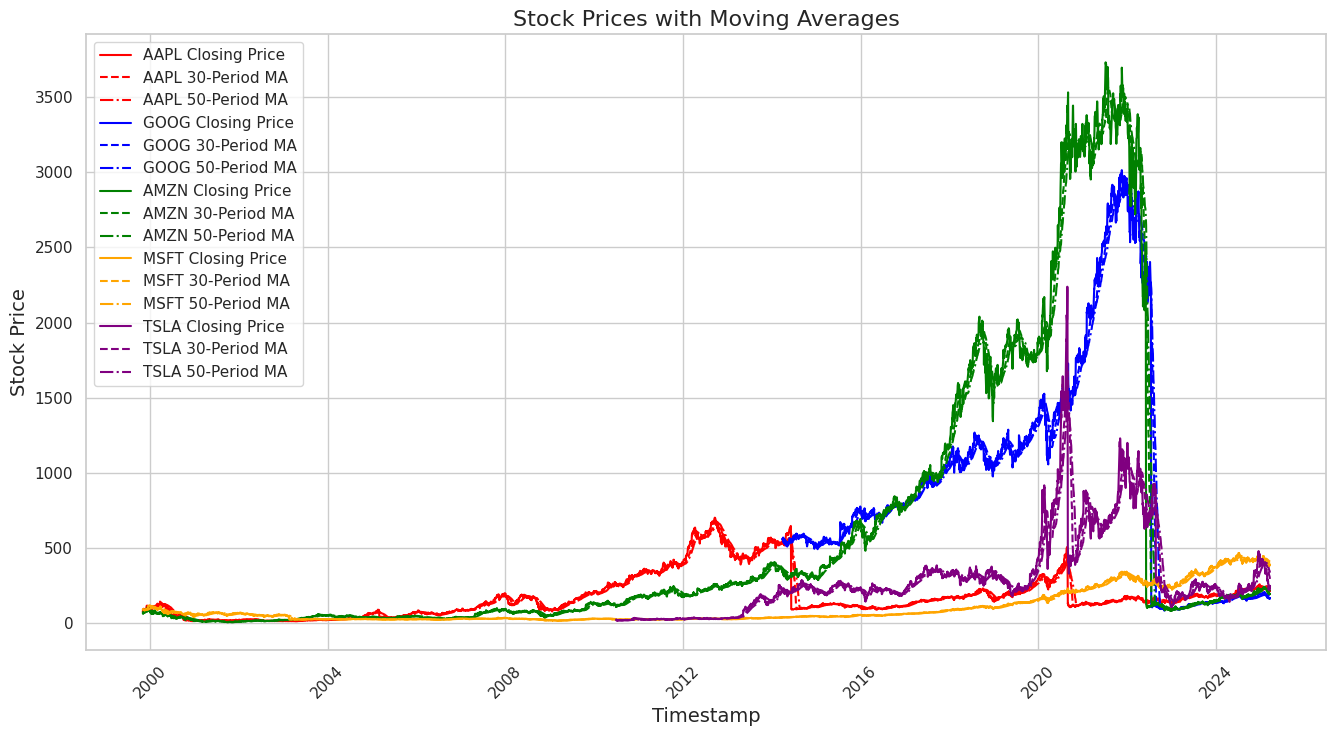

In [80]:
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import pandas as pd

# List of company symbols
company_symbols = ['AAPL', 'GOOG', 'AMZN', 'MSFT', 'TSLA']

# Filter data for selected companies & order by timestamp
filtered_df = spark_df.filter(F.col('symbol').isin(company_symbols)).orderBy(['symbol', 'timestamp'])

# Define a 30-period rolling window for moving average
windowSpec_30 = Window.partitionBy('symbol').orderBy('timestamp').rowsBetween(-30, 0)

# Calculate 30-period rolling mean for each stock
filtered_df = filtered_df.withColumn('rolling_mean_30', F.avg('close').over(windowSpec_30))

# Define a 50-period rolling window for moving average
windowSpec_50 = Window.partitionBy('symbol').orderBy('timestamp').rowsBetween(-50, 0)

# Calculate 50-period rolling mean for each stock
filtered_df = filtered_df.withColumn('rolling_mean_50', F.avg('close').over(windowSpec_50))

# Convert PySpark DataFrame to Pandas DataFrame for easier plotting
pd_df = filtered_df.toPandas()
pd_df['timestamp'] = pd.to_datetime(pd_df['timestamp'])  # Ensure proper datetime format

# Plot Moving Averages for Each Company
plt.figure(figsize=(16, 8))
colors = ['red', 'blue', 'green', 'orange', 'purple']
linestyles = ['solid', 'dashed', 'dashdot', 'dotted', 'solid']

for idx, symbol in enumerate(company_symbols):
    symbol_data = pd_df[pd_df['symbol'] == symbol]
    plt.plot(symbol_data['timestamp'], symbol_data['close'], label=f'{symbol} Closing Price', color=colors[idx], linestyle='solid', linewidth=1.5)
    plt.plot(symbol_data['timestamp'], symbol_data['rolling_mean_30'], label=f'{symbol} 30-Period MA', color=colors[idx], linestyle='dashed', linewidth=1.5)
    plt.plot(symbol_data['timestamp'], symbol_data['rolling_mean_50'], label=f'{symbol} 50-Period MA', color=colors[idx], linestyle='dashdot', linewidth=1.5)

# Formatting
plt.xlabel('Timestamp', fontsize=14)
plt.ylabel('Stock Price', fontsize=14)
plt.title('Stock Prices with Moving Averages', fontsize=16)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Show plot
plt.show()


Moving averages are statistical tools used in stock market analysis that help identify trends by reducing noise in price data. All 5 companies (APPL, MSFT, GOOG, TSLA, and AMZN) are plotted with 30-day and 50-day rolling averages, where the average closing price over the respective time periods are claculated. These moving averages reduce fluctuations in short termto get more clear overall trends. All 5 stocks move in the upward trend.

# Descriptive Analysis

In [20]:
from pyspark.sql.functions import col

# Ensure company_symbols list exists
company_symbols = ['AAPL', 'GOOG', 'AMZN', 'MSFT', 'TSLA']

# Display summary statistics for each selected company
for company in company_symbols:
    # Filter DataFrame for the current company
    current_company_df = filtered_df.filter(col('symbol') == company)

    # Compute summary statistics (more detailed than describe())
    current_company_summary_stats = current_company_df.summary()

    # Convert to Pandas for better visualization
    print(f"\n🔹 Summary Statistics for {company} 🔹")
    print(current_company_summary_stats.toPandas().to_string(index=False))  # Neat table format
    print("\n" + "="*60 + "\n")  # Separator line for clarity



🔹 Summary Statistics for AAPL 🔹
summary  timestamp               open               high                low              close               volume symbol    rolling_mean_30    rolling_mean_50
  count        100                100                100                100                100                  100    100                100                100
   mean       None 234.78015000000022 237.36533699999993  232.5533300000001 235.16850000000005         5.01308673E7   None 235.46784835548237 235.07047523373186
 stddev       None 11.112861178073416 10.930401077697198 11.212632408825968 11.167337598568603 1.8270221488077503E7   None  6.004461365921064   4.95826027671919
    min 2024-10-25             211.25             213.95             208.42             209.68             23234705   AAPL 226.67624999999998 226.67624999999998
    25%       None              226.4             229.74              225.0             227.48             39480718   None  230.7276666666667  230.7276666666667
 

The summary statistics for all 5 stocks include count, mean, standard deviation, minimum, and maximum values for various financial metrics in stock market such as volume, open, high, low, close, adjclose, along with rolling mean values for a 30-day and 50-day period. AMZN has higher mean values for all atrributes, exhibiting higher average trading volume and stock prices. TSLA exhibits higher volatility, indicating a greater degree of price variability and market uncertainty compared to the other stocks. GOOG shows relatively strong performance, indicating that the calculated rolling means for this stock exhibit a consistent and positive trend over time.

# AAPL Stock

Available columns in stock_df: Index(['timestamp', 'open', 'high', 'low', 'close', 'volume', 'symbol'], dtype='object')


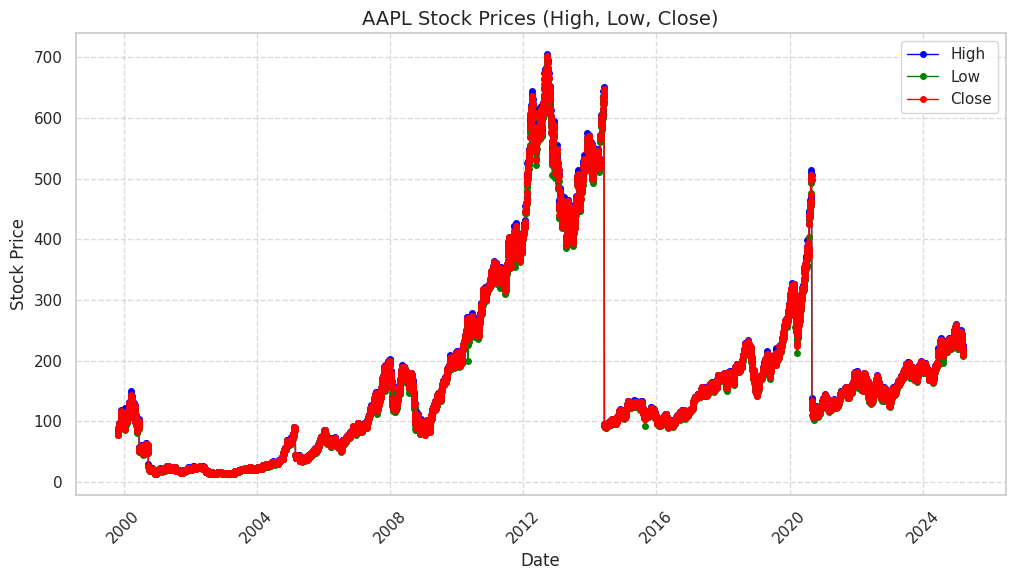

In [81]:
import matplotlib.pyplot as plt
import pandas as pd

# Select stock symbol
selected_stock = 'AAPL'

# Convert to Pandas for easier plotting
stock_df = spark_df.filter(F.col('symbol') == selected_stock).toPandas()

# Debug: Print available columns to check if 'date' exists
print("Available columns in stock_df:", stock_df.columns)

# Check if 'date' exists, otherwise try 'timestamp'
if 'date' not in stock_df.columns:
    if 'timestamp' in stock_df.columns:
        stock_df.rename(columns={'timestamp': 'date'}, inplace=True)
    else:
        raise KeyError("Neither 'date' nor 'timestamp' column found in the dataset.")

# Convert 'date' to datetime format
stock_df['date'] = pd.to_datetime(stock_df['date'])

# Define columns to plot (ensure 'adjclose' exists)
columns_to_plot = ['high', 'low', 'close']
if 'adjclose' in stock_df.columns:
    columns_to_plot.append('adjclose')

# Define colors for better differentiation
colors = ['blue', 'green', 'red', 'purple']

# Plot
plt.figure(figsize=(12, 6))
for col, color in zip(columns_to_plot, colors):
    plt.plot(stock_df['date'], stock_df[col], label=col.capitalize(), color=color, marker='o', markersize=4, linewidth=1)

plt.title(f'{selected_stock} Stock Prices (High, Low, Close)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stock Price', fontsize=12)
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


AAPL stock is decreased till 2016; after 2016, there was an upward trend eventhough it decreases in later years. Open is basically closing price of the previous day; so, open is not considered. It can be noted that there is no visible variations in high, low, close, and adjclose values, indicating all are more similar to one another.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

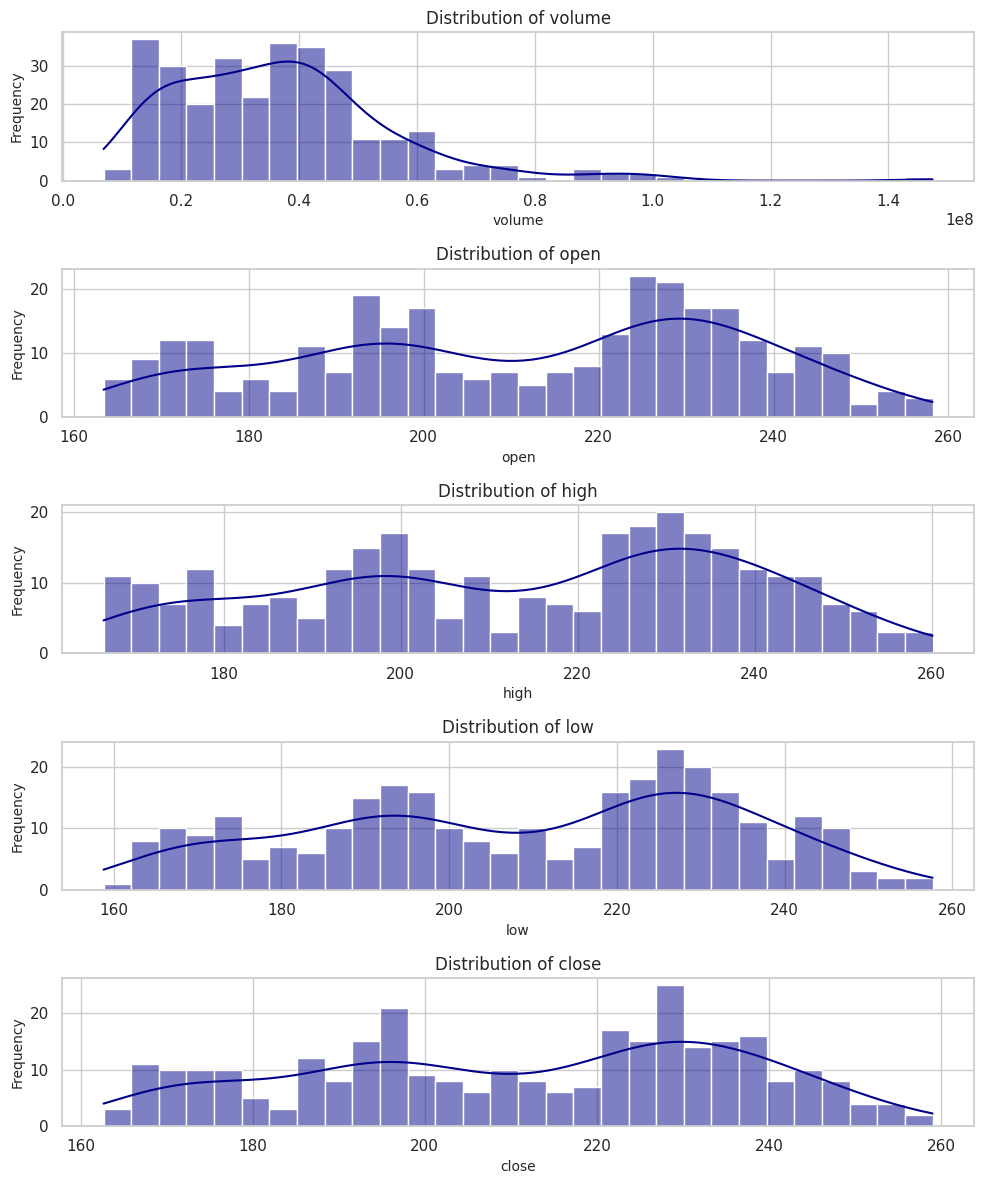

In [21]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Check available columns before selecting numerical ones
available_columns = pandas_df.columns
numerical_columns = ['volume', 'open', 'high', 'low', 'close']

# Include 'adjclose' only if it exists in the DataFrame
if 'adjclose' in available_columns:
    numerical_columns.append('adjclose')

# Drop NaN values for clean plotting
pandas_df = pandas_df[numerical_columns].dropna()

# Set up seaborn style for better visuals
sns.set_style("whitegrid")

# Set up subplots
fig, axes = plt.subplots(nrows=len(numerical_columns), ncols=1, figsize=(10, 12))

# Plot histograms with KDE (Kernel Density Estimation)
for i, column in enumerate(numerical_columns):
    sns.histplot(pandas_df[column], bins=30, kde=True, ax=axes[i], color='darkblue')
    axes[i].set_title(f'Distribution of {column}', fontsize=12)
    axes[i].set_xlabel(column, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


Histograms are used to fine the distribution of each column. As mentioned above, all open, close, high, low, and adjclose are similar. Hence, all plots are showing the same frqency plots other than volume

# Pair Plot

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert PySpark DataFrame to Pandas DataFrame
pandas_df = filtered_df.toPandas()

# Check available columns before selecting numerical ones
available_columns = pandas_df.columns
numerical_columns = ['volume', 'high', 'low', 'close']

# Include 'adjclose' only if it exists in the DataFrame
if 'adjclose' in available_columns:
    numerical_columns.append('adjclose')

# Drop NaN values to avoid issues in plotting
pandas_df = pandas_df[numerical_columns].dropna()

# Set Seaborn style for a cleaner look
sns.set_style("whitegrid")

# Scatter Plot Matrix
scatter_matrix = sns.pairplot(pandas_df, diag_kind='kde', height=2.5)
plt.suptitle('Scatter Plot Matrix', fontsize=14)
plt.show()

# Density Plot Matrix
density_matrix = sns.pairplot(pandas_df, kind='kde', height=2.5)
plt.suptitle('Density Plot Matrix', fontsize=14)
plt.show()


These plots are used to identify where the majority of values lie and to determine whether there is any relationship between each feature.

# Correlation Heatmap

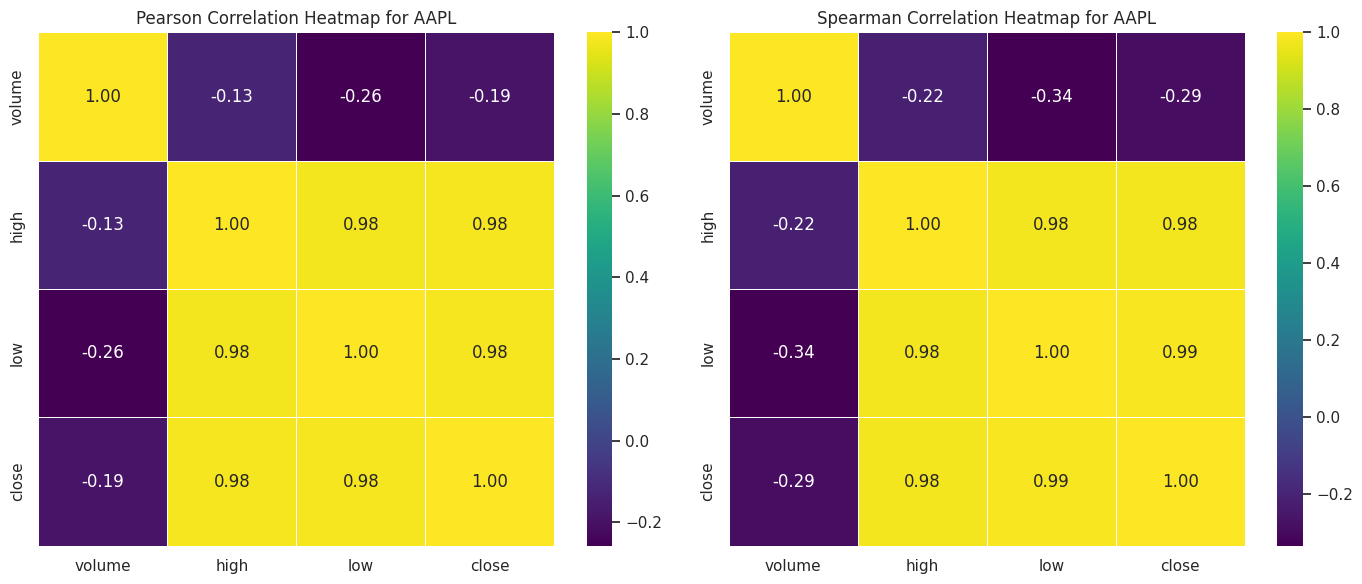

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql.functions import col

# Select only numerical columns
numerical_columns = ['volume', 'high', 'low', 'close']

# Check if 'adjclose' exists in the DataFrame before selection
if 'adjclose' in filtered_df.columns:
    numerical_columns.append('adjclose')

# Filter DataFrame to include only 'AAPL' stock and numerical columns
aapl_df = filtered_df.filter(col('symbol') == 'AAPL').select(*numerical_columns)

# Convert to Pandas and handle NaN values
pandas_df_aapl = aapl_df.toPandas().dropna()

# Ensure we have valid data before proceeding
if not pandas_df_aapl.empty:
    # Calculate Pearson and Spearman correlation
    pearson_corr_aapl = pandas_df_aapl.corr(method='pearson')
    spearman_corr_aapl = pandas_df_aapl.corr(method='spearman')

    # Set up subplots
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

    # Pearson Correlation Heatmap
    sns.heatmap(pearson_corr_aapl, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5, ax=axes[0])
    axes[0].set_title('Pearson Correlation Heatmap for AAPL')

    # Spearman Correlation Heatmap
    sns.heatmap(spearman_corr_aapl, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5, ax=axes[1])
    axes[1].set_title('Spearman Correlation Heatmap for AAPL')

    plt.tight_layout()
    plt.show()
else:
    print("No valid data available for AAPL.")


To check the correlation,

if the value is near to -1, then it is strong negative correlation

if the value is near to 0, then it is weak correlation

if the value is near to +1, then it is strong positive correlation

As the values of high, low, close, and adjclose are the same, all the correlation is represented as 1.


# Stop the SparkSession
spark.stop()

In [91]:
# For processing
import math
import random
import datetime as dt
import matplotlib.dates as mdates


# Libraries for model training
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error

In [92]:
from pyspark.sql.functions import col

# Filtering apple dataset

aapl_df = ['AAPL']
aapl_spark = filtered_df.filter(col('symbol').isin(aapl_df))

# Show the filtered apple dataset
aapl_spark.show()

+----------+-----+-----+-----+-----+-------+------+-----------------+-----------------+
| timestamp| open| high|  low|close| volume|symbol|  rolling_mean_30|  rolling_mean_50|
+----------+-----+-----+-----+-----+-------+------+-----------------+-----------------+
|1999-11-01| 80.0|80.69|77.37|77.62|2487300|  AAPL|            77.62|            77.62|
|1999-11-02| 78.0|81.69|77.31|80.25|3564600|  AAPL|           78.935|           78.935|
|1999-11-03|81.62|83.25| 81.0| 81.5|2932700|  AAPL|            79.79|            79.79|
|1999-11-04|82.06|85.37|80.62|83.62|3384700|  AAPL|          80.7475|          80.7475|
|1999-11-05|84.62|88.37| 84.0|88.31|3721500|  AAPL|            82.26|            82.26|
|1999-11-08|87.75|97.73|86.75|96.37|8490400|  AAPL|84.61166666666666|84.61166666666666|
|1999-11-09|94.37| 94.5| 88.0|89.62|7224800|  AAPL|85.32714285714285|85.32714285714285|
|1999-11-10|88.25|93.25|88.12|91.44|5159800|  AAPL|         86.09125|         86.09125|
|1999-11-11|91.59|92.62|89.87|92

APPL stock is filtered out from the total of 5 stocks.

In [93]:
#Converting apple spark dataset to pandas
aapl_df = aapl_spark.toPandas()

In [94]:
#show apple dataframe
aapl_df

,timestamp,open,high,low,close,volume,symbol,rolling_mean_30,rolling_mean_50
0,1999-11-01,80.00,80.6900,77.37,77.62,2487300,AAPL,77.620000,77.620000
1,1999-11-02,78.00,81.6900,77.31,80.25,3564600,AAPL,78.935000,78.935000
2,1999-11-03,81.62,83.2500,81.00,81.50,2932700,AAPL,79.790000,79.790000
3,1999-11-04,82.06,85.3700,80.62,83.62,3384700,AAPL,80.747500,80.747500
4,1999-11-05,84.62,88.3700,84.00,88.31,3721500,AAPL,82.260000,82.260000
...,...,...,...,...,...,...,...,...,...
6381,2025-03-17,213.31,215.2200,209.97,214.00,48073426,AAPL,234.010645,234.519412
6382,2025-03-18,214.16,215.1500,211.49,212.69,42432426,AAPL,233.258710,233.779608
6383,2025-03-19,214.22,218.7600,213.75,215.24,54385391,AAPL,232.846774,233.218627
6384,2025-03-20,213.99,217.4899,212.22,214.10,48862947,AAPL,232.243548,232.644902


In [95]:
#Creating new data frame for building model with close values from apple dataframe.
new_df = aapl_df.reset_index()['close']

In [96]:
# For processing
import math
import random
import datetime as dt
import matplotlib.dates as mdates


# Libraries for model training
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error

In [97]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(new_df.values.reshape(-1, 1))


Normalization of the values is performed to make all the values to be consistent, so the optimization algorthms work faster and all the values are treated equally.

In [98]:
scaled_data.shape

(6386, 1)

In [99]:
# Split into training and testing sets
train_size = int(len(scaled_data) * 0.8)  # 80% for training
train_data, test_data = scaled_data[:train_size], scaled_data[train_size:]

80% of data is used for training of the model.

In [100]:
n_past = 300  # Increased sequence length for better trend learning

# Prepare training sequences
X_train, y_train = [], []
for i in range(n_past, len(train_data)):
    X_train.append(train_data[i - n_past:i, 0])
    y_train.append(train_data[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

# Prepare test sequences
X_test, y_test = [], []
for i in range(n_past, len(test_data)):
    X_test.append(test_data[i - n_past:i, 0])
    y_test.append(test_data[i, 0])
X_test, y_test = np.array(X_test), np.array(y_test)

Sequences of length from training and testing data for training an LSTM model is created, where each sequence represents a historical window used to predict the next time step.

In [101]:
print("Training set size:-")
print(X_train.shape), print(y_train.shape)
print("\n")
print("Testing set size:-")
print(X_test.shape), print(y_test.shape)

Training set size:-
(4808, 300)
(4808,)


Testing set size:-
(978, 300)
(978,)


(None, None)

In [102]:
# Reshape input data for LSTM([samples, time steps, features])
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [105]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Initialize a sequential model
model = Sequential()

# Explicitly define the input layer
model.add(Input(shape=(X_train.shape[1], 1)))

# First LSTM layer with 50 units and return sequences
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))  # Adding dropout to prevent overfitting

# Second LSTM layer with 50 units and return sequences
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# Third LSTM layer with 50 units
model.add(LSTM(units=50))
model.add(Dropout(0.2))

# Add a dense output layer with one unit
model.add(Dense(units=1))

# Model summary
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                        │ (None, 300, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 300, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_9 (LSTM)                        │ (None, 300, 50)             │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 300, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_10 (LSTM)                       │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

A sequential model for a Long Short-Term Memory (LSTM) neural network with three layers is initialized, each containing 50 units, and dropout layers to prevent overfitting, followed by a dense output layer with one unit.

In [41]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 30, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 30, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 30, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 30, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [106]:
model.compile(loss='mean_squared_error',optimizer='adam')

!pip install --upgrade tensorflow keras


In [107]:
# Training our lstm model
history = model.fit(X_train, y_train,validation_data=(X_test,y_test),epochs=50,batch_size=64)

Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 38s 442ms/step - loss: 0.0231 - val_loss: 1.8480e-04
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 425ms/step - loss: 0.0027 - val_loss: 4.4186e-04
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 34s 442ms/step - loss: 0.0024 - val_loss: 2.5355e-04
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 33s 436ms/step - loss: 0.0021 - val_loss: 1.4701e-04
Epoch 5/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 33s 437ms/step - loss: 0.0024 - val_loss: 1.0760e-04
Epoch 6/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 33s 436ms/step - loss: 0.0015 - val_loss: 1.1059e-04
Epoch 7/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 33s 431ms/step - loss: 0.0013 - val_loss: 1.3833e-04
Epoch 8/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 424ms/step - loss: 0.0021 - val_loss: 1.0145e-04
Epoch 9/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 33s 429ms/step - loss: 0.0017 - val_loss: 1.2628e-04
Epoch 10/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 33s 430ms/step - loss: 0.0012 - val_loss: 3.8609e-04
Epoch 11/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 33s 433ms/step - loss: 0.0016 - val_loss: 7.9867e-

An LSTM model is trained using historical data with 50 epochs, a batch size of 64, and validation data, storing the training history in the 'history' variable.

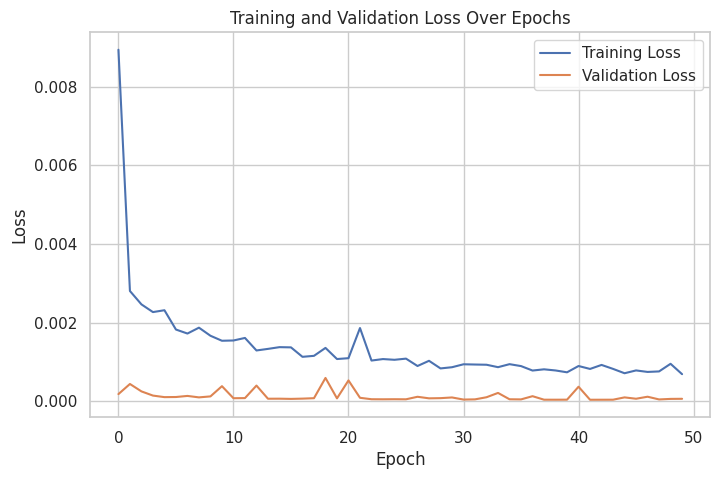

In [108]:
# Plot training loss and validation loss across epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

The training loss remains consistently low and stable, while the validation loss exhibits slight variations.

In [109]:
# Let's do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

151/151 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step


In [110]:
test_predict

array([[0.1687823 ],
       [0.16821238],
       [0.16756508],
       [0.16605386],
       [0.16418502],
       [0.1628532 ],
       [0.16229999],
       [0.16158874],
       [0.16050246],
       [0.15864803],
       [0.15702501],
       [0.15649684],
       [0.15657902],
       [0.15658465],
       [0.15636657],
       [0.15657653],
       [0.15672141],
       [0.157056  ],
       [0.15745352],
       [0.157787  ],
       [0.1576717 ],
       [0.15709886],
       [0.15628257],
       [0.15566143],
       [0.15500972],
       [0.15489313],
       [0.15521596],
       [0.15589868],
       [0.15675083],
       [0.15731458],
       [0.15780137],
       [0.15888369],
       [0.16009697],
       [0.16121686],
       [0.16242635],
       [0.16325808],
       [0.16405779],
       [0.16515805],
       [0.166273  ],
       [0.16711311],
       [0.16755572],
       [0.1680546 ],
       [0.16894507],
       [0.17013106],
       [0.17135753],
       [0.17296529],
       [0.17506869],
       [0.177

In [111]:
# Transform back to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [112]:
y_train = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

In [113]:
y_test

array([[131.46 ],
       [132.54 ],
       [127.85 ],
       [128.1  ],
       [129.74 ],
       [130.21 ],
       [126.85 ],
       [125.91 ],
       [122.77 ],
       [124.97 ],
       [127.45 ],
       [126.27 ],
       [124.85 ],
       [124.69 ],
       [127.31 ],
       [125.43 ],
       [127.1  ],
       [126.9  ],
       [126.85 ],
       [125.28 ],
       [124.61 ],
       [124.28 ],
       [125.06 ],
       [123.54 ],
       [125.89 ],
       [125.9  ],
       [126.74 ],
       [127.13 ],
       [126.11 ],
       [127.35 ],
       [130.48 ],
       [129.64 ],
       [130.15 ],
       [131.79 ],
       [130.46 ],
       [132.3  ],
       [133.98 ],
       [133.7  ],
       [133.41 ],
       [133.11 ],
       [134.78 ],
       [136.33 ],
       [136.96 ],
       [137.27 ],
       [139.96 ],
       [142.02 ],
       [144.57 ],
       [143.24 ],
       [145.11 ],
       [144.5  ],
       [145.64 ],
       [149.15 ],
       [148.48 ],
       [146.39 ],
       [142.45 ],
       [14

# Calculate train data RMSE
print(math.sqrt(mean_squared_error(y_train,train_predict)))
# Calculate test data RMSE
print(math.sqrt(mean_squared_error(y_test,test_predict)))

In [119]:
# Calculate train data RMSE
print(math.sqrt(mean_squared_error(y_train,train_predict)))
# Calculate test data RMSE
print(math.sqrt(mean_squared_error(y_test,test_predict)))

12.050026259451535
5.569847203425929


In [120]:
from sklearn.metrics import mean_absolute_percentage_error

In [52]:
MAPE = mean_absolute_percentage_error(y_test, test_predict)
Accuracy = 1 - MAPE

print(MAPE)
print(Accuracy)

0.10620583126770336
0.8937941687322967


MAPE is calculated for the predicted values against the actual values, resulting in an accuracy of 95.03%.

In [121]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, test_predict)
print(f'R-squared: {r2}')

R-squared: 0.9697672630119596


The R2 value of 0.75 suggests that the model explains about 75% of the variability in the data, indicating a moderately good fit.

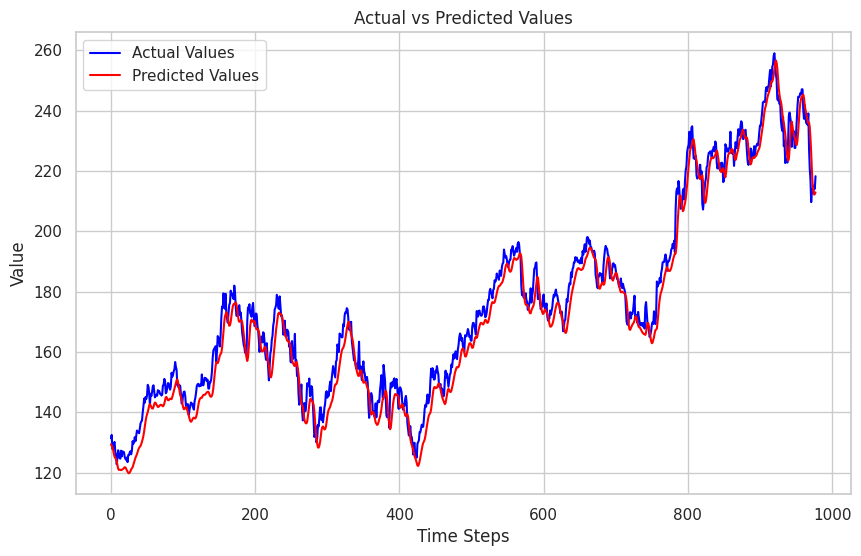

In [114]:
# Visualize the actual and predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual Values', color='blue')
plt.plot(test_predict, label='Predicted Values', color='red')
plt.title('Actual vs Predicted Values')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.show()

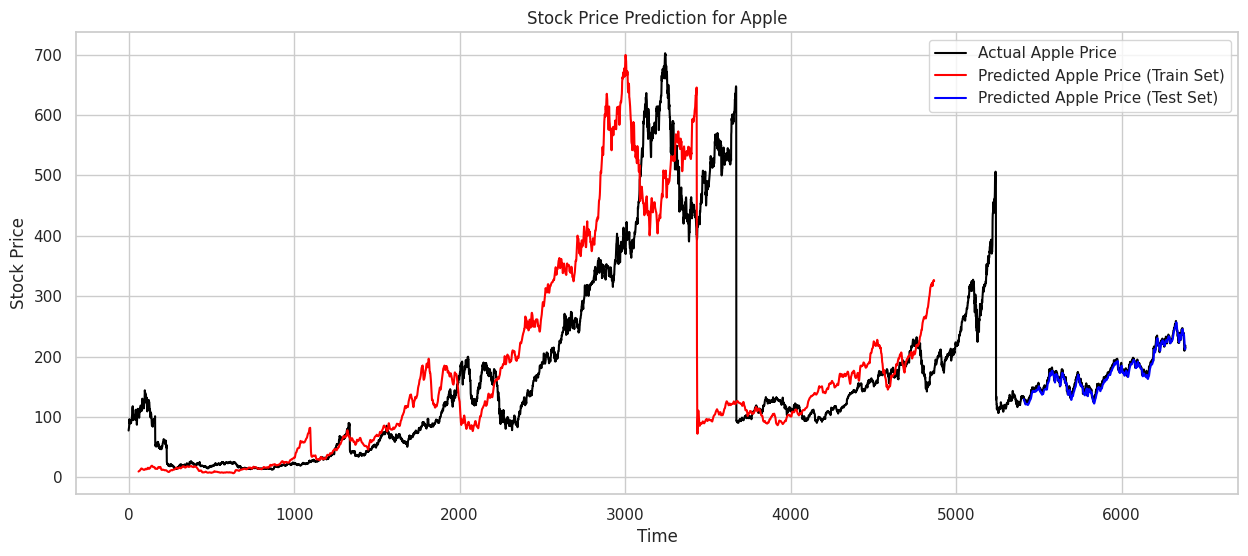

In [115]:
# Set the number of previous time steps to consider for plotting
look_back = 60

# Initialize an array for plotting the train predictions
trainPredictPlot = np.empty_like(scaled_data)
trainPredictPlot[:, :] = np.nan  # Ensure it's properly initialized

# Ensure correct slicing for train predictions
train_end = look_back + len(train_predict)  # Determine end index
if train_end > len(trainPredictPlot):
    train_end = len(trainPredictPlot)  # Prevent out-of-bounds error
trainPredictPlot[look_back:train_end] = train_predict[:train_end - look_back]

# Initialize an array for plotting the test predictions
testPredictPlot = np.empty_like(scaled_data)
testPredictPlot[:, :] = np.nan  # Ensure it's properly initialized

# Calculate the starting index for the test predictions
test_start = len(scaled_data) - len(test_predict)
if test_start < 0:
    test_start = 0  # Prevent negative indexing
testPredictPlot[test_start:test_start + len(test_predict)] = test_predict[:len(scaled_data) - test_start]

# Rescale the scaled data back to its original scale using the scaler
original_scaled_data = scaler.inverse_transform(scaled_data)

# Plot the actual vs. predicted values
plt.figure(figsize=(15, 6))
plt.plot(original_scaled_data, color='black', label="Actual Apple Price")
plt.plot(trainPredictPlot, color='red', label="Predicted Apple Price (Train Set)")
plt.plot(testPredictPlot, color='blue', label="Predicted Apple Price (Test Set)")

plt.title("Stock Price Prediction for Apple")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


Previous 60 time steps are considered for plotting, and arrays are initialized to visualize the training and test predictions compared to the actual Apple stock prices, with predictions rescaled back to the original scale using the scaler.

In [116]:
# To predict for the next 10 days, you'll need the last n_past days of data
last_sequence = X_test[-1]

# Reshape the last_sequence to match the input shape of the model
last_sequence = last_sequence.reshape(1, n_past, 1)

# Generate predictions for the next 10 days
predictions_next_10_days = []
for _ in range(10):
    next_day_prediction = model.predict(last_sequence)
    predictions_next_10_days.append(next_day_prediction[0, 0])  # Get the predicted value
    last_sequence = np.roll(last_sequence, -1, axis=1)  # Shift the sequence by one day
    last_sequence[0, -1, 0] = next_day_prediction  # Update the last element with the new prediction

# Transform the predictions back to the original scale
predictions_next_10_days = scaler.inverse_transform(np.array(predictions_next_10_days).reshape(-1, 1))

# Print the predictions for the next 10 days
print("Predictions for the next 10 days:")
for i, prediction in enumerate(predictions_next_10_days, start=1):
    print(f"Day {i}: Predicted Price = {prediction[0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


<ipython-input-116-f2a8e5ff3395>:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  last_sequence[0, -1, 0] = next_day_prediction  # Update the last element with the new prediction


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predictions for the next 10 days:
Day 1: Predicted Price = 212.89266967773438
Day 2: Predicted Price = 213.09324645996094
Day 3: Predicted Price = 212.97125244140625
Day 4: Predicted Price = 212.63882446289062
Day 5: Predicted Price = 212.17918395996094
Day 6: Predicted Price = 211.63998413085938
Day 7: Predicted Price = 211.04928588867188
Day 8: Predicted Price = 210.42617797851562
Day 9: Predicted Price = 209.7850341796875
Day 10: Predicted Price = 209.1363525390625


The stock prices for the next 10 days using an LSTM model was predicted, generating predictions iteratively, and then transforming the predictions back to the original scale.

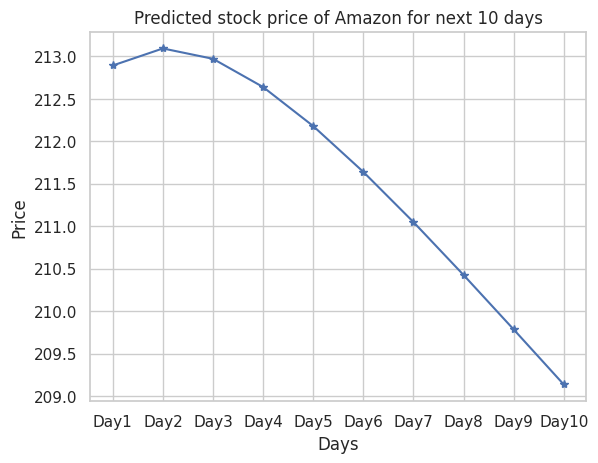

In [117]:
plt.plot(predictions_next_10_days, marker='*')
plt.title(f'Predicted stock price of Amazon for next 10 days')
plt.xlabel('Days')
plt.ylabel('Price')
plt.xticks(range(0, 10), ['Day1', 'Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7', 'Day8', 'Day9', 'Day10'])
plt.grid(True)
plt.show()

From the above graph, it can be concluded that the price of the AAPL stock will decrease for the next 10 days.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [118]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Inverse transform predictions and actual values to original scale
train_predict_original = scaler.inverse_transform(train_predict)
test_predict_original = scaler.inverse_transform(test_predict)
y_train_original = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))

# Compute evaluation metrics for training data
train_mae = mean_absolute_error(y_train_original, train_predict_original)
train_mse = mean_squared_error(y_train_original, train_predict_original)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train_original, train_predict_original)

# Compute evaluation metrics for testing data
test_mae = mean_absolute_error(y_test_original, test_predict_original)
test_mse = mean_squared_error(y_test_original, test_predict_original)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test_original, test_predict_original)

# Print evaluation results
print("🔹 Model Evaluation Metrics:")
print("\n📌 *Training Set Metrics*")
print(f"   - MAE  : {train_mae:.4f}")
print(f"   - MSE  : {train_mse:.4f}")
print(f"   - RMSE : {train_rmse:.4f}")
print(f"   - R² Score : {train_r2:.4f}")

print("\n📌 *Testing Set Metrics*")
print(f"   - MAE  : {test_mae:.4f}")
print(f"   - MSE  : {test_mse:.4f}")
print(f"   - RMSE : {test_rmse:.4f}")
print(f"   - R² Score : {test_r2:.4f}")

🔹 Model Evaluation Metrics:

📌 *Training Set Metrics*
   - MAE  : 4509.3515
   - MSE  : 68926973.3743
   - RMSE : 8302.2270
   - R² Score : 0.9945

📌 *Testing Set Metrics*
   - MAE  : 3174.0368
   - MSE  : 14726507.8150
   - RMSE : 3837.5132
   - R² Score : 0.9698
